# 05 — Árbol de regresión con poda por costo-complejidad

**TP Final · Aprendizaje de Máquina I (CEIA-FIUBA)** · Jaime Pinzón (a2629)

## Justificación del modelo (criterio oficial 5)

**Qué es.** Un árbol de regresión divide el espacio de features en regiones rectangulares mediante particiones binarias recursivas (*recursive binary splitting*, algoritmo voraz top-down): en cada nodo elige el par (feature, punto de corte) que más reduce el error cuadrático, y predice en cada hoja la media de sus observaciones.

**Por qué tiene sentido acá.** (i) **Interpretabilidad**: el árbol podado produce reglas legibles del tipo "si el paciente tiene más de X medicaciones y diagnóstico primario circulatorio, la estadía esperada sube a Y días" — oro para comunicar al dominio hospitalario, algo que ni KNN ni SVR ofrecen. (ii) Captura interacciones automáticamente (cada rama es una interacción). (iii) Es la base de los ensambles de la semana 3: entender el árbol individual es entender qué promedia un Random Forest.

**Por qué NO se escala (`build_preprocessor(scale=False)`).** El árbol elige umbrales de corte por feature de forma independiente: la pregunta "¿`num_medications` ≤ 15,5?" define la misma partición con la variable cruda que con la estandarizada — las divisiones son **invariantes a transformaciones monótonas** de cada feature. Estandarizar solo haría los umbrales ilegibles (¿"medicaciones ≤ 0,37 desvíos"?) sin cambiar el modelo.

**El riesgo central: sobreajuste.** Sin restricciones, el algoritmo puede crecer hasta una hoja por observación (error de train ≈ 0, generalización pésima). Este notebook lo **demuestra** primero y después lo corrige con la estrategia recomendada en la materia: crecer el árbol completo y podarlo con el parámetro de costo-complejidad **α** (`ccp_alpha`), que penaliza el número de hojas — la secuencia de subárboles óptimos es anidada y determinista, y α se elige por validación cruzada.

**Ventajas / desventajas.**
- ✅ Interpretable; sin escalado; maneja mezclas de tipos de features; base de los ensambles.
- ❌ Alta varianza (pequeños cambios en los datos cambian el árbol); fronteras solo perpendiculares a los ejes; un solo árbol rara vez es el mejor predictor — por eso la semana 3 lo ensambla.

In [1]:
import time

import pandas as pd
from sklearn.model_selection import KFold

from src.config import DIR_PROCESSED, SEED, TARGET
from src.evaluacion import evaluar, registrar
from src.pipelines import build_preprocessor

X_train = pd.read_parquet(DIR_PROCESSED / "X_train.parquet")
X_test = pd.read_parquet(DIR_PROCESSED / "X_test.parquet")
y_train = pd.read_parquet(DIR_PROCESSED / "y_train.parquet")[TARGET]
y_test = pd.read_parquet(DIR_PROCESSED / "y_test.parquet")[TARGET]

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
print(f"train: {X_train.shape} | test: {X_test.shape}")

train: (53756, 8) | test: (20354, 8)


In [2]:
# --- Demostracion del sobreajuste: arbol sin restricciones ---
# NOTA: esta variante es SOLO una demostracion didactica (train vs CV).
# No se evalua sobre test ni se registra en metricas.csv: alli van
# unicamente los candidatos reales, y este arbol no lo es por diseño.
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

pipe_libre = Pipeline([
    ("preprocesador", build_preprocessor(scale=False)),
    ("modelo", DecisionTreeRegressor(random_state=SEED)),
])
pipe_libre.fit(X_train, y_train)

from sklearn.metrics import mean_absolute_error
mae_train = mean_absolute_error(y_train, pipe_libre.predict(X_train))
mae_cv = -cross_val_score(
    pipe_libre, X_train, y_train, cv=cv,
    scoring="neg_mean_absolute_error", n_jobs=-1,
).mean()

arbol_libre = pipe_libre.named_steps["modelo"]
print(f"Arbol sin restricciones: {arbol_libre.get_n_leaves():,} hojas, "
      f"profundidad {arbol_libre.get_depth()}")
print(f"MAE en train: {mae_train:.4f} dias  <- casi memoriza")
print(f"MAE en CV   : {mae_cv:.4f} dias  <- la generalizacion real")
print(f"Brecha train-CV: {mae_cv - mae_train:.2f} dias = sobreajuste puro")

Arbol sin restricciones: 35,854 hojas, profundidad 38
MAE en train: 0.9713 dias  <- casi memoriza
MAE en CV   : 2.3183 dias  <- la generalizacion real
Brecha train-CV: 1.35 dias = sobreajuste puro


In [3]:
# --- Camino de poda por costo-complejidad (todo dentro del pipeline ya fiteado) ---
import numpy as np

prep_fiteado = pipe_libre.named_steps["preprocesador"]   # fiteado SOLO con train
Xt_train = prep_fiteado.transform(X_train)
camino = pipe_libre.named_steps["modelo"].cost_complexity_pruning_path(Xt_train, y_train)

alphas_todos = np.unique(camino.ccp_alphas)
print(f"El camino de poda tiene {len(alphas_todos):,} alphas distintos")

# ~25 candidatos log-espaciados sobre los cuantiles del camino (mas alpha=0)
cuantiles = np.linspace(0.5, 0.999, 24)
candidatos = np.unique(np.quantile(alphas_todos[alphas_todos > 0], cuantiles))
candidatos = np.concatenate([[0.0], candidatos])
print(f"Se evaluan {len(candidatos)} alphas candidatos por CV de 5 folds")

El camino de poda tiene 9,875 alphas distintos
Se evaluan 25 alphas candidatos por CV de 5 folds


In [4]:
# --- CV sobre los alphas candidatos (el preprocesador se re-fitea por fold) ---
resultados_alpha = []
t0 = time.perf_counter()
for alpha in candidatos:
    p = Pipeline([
        ("preprocesador", build_preprocessor(scale=False)),
        ("modelo", DecisionTreeRegressor(ccp_alpha=alpha, random_state=SEED)),
    ])
    mae = -cross_val_score(
        p, X_train, y_train, cv=cv,
        scoring="neg_mean_absolute_error", n_jobs=-1,
    ).mean()
    resultados_alpha.append({"alpha": alpha, "mae_cv": mae})
t_cv_alphas = time.perf_counter() - t0

tabla_alphas = pd.DataFrame(resultados_alpha)
mejor = tabla_alphas.loc[tabla_alphas["mae_cv"].idxmin()]
print(f"CV de {len(candidatos)} alphas en {t_cv_alphas/60:.1f} min")
print(f"Mejor alpha: {mejor['alpha']:.2e} con MAE(CV) = {mejor['mae_cv']:.4f} dias")

CV de 25 alphas en 2.3 min
Mejor alpha: 9.62e-04 con MAE(CV) = 1.7362 dias


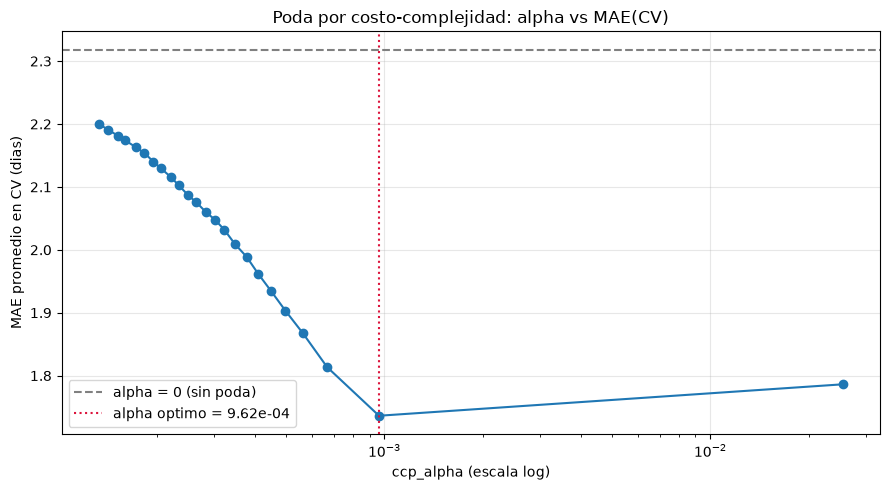

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
positivos = tabla_alphas[tabla_alphas["alpha"] > 0]
ax.plot(positivos["alpha"], positivos["mae_cv"], marker="o")
ax.axhline(tabla_alphas.loc[tabla_alphas["alpha"] == 0, "mae_cv"].iloc[0],
           color="gray", linestyle="--", label="alpha = 0 (sin poda)")
ax.axvline(mejor["alpha"], color="crimson", linestyle=":",
           label=f"alpha optimo = {mejor['alpha']:.2e}")
ax.set_xscale("log")
ax.set_xlabel("ccp_alpha (escala log)")
ax.set_ylabel("MAE promedio en CV (dias)")
ax.set_title("Poda por costo-complejidad: alpha vs MAE(CV)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [6]:
# --- Arbol final podado: refit sobre train completo + test (una vez) ---
pipe_podado = Pipeline([
    ("preprocesador", build_preprocessor(scale=False)),
    ("modelo", DecisionTreeRegressor(ccp_alpha=mejor["alpha"], random_state=SEED)),
])
t0 = time.perf_counter()
pipe_podado.fit(X_train, y_train)
t_podado = time.perf_counter() - t0

arbol = pipe_podado.named_steps["modelo"]
print(f"Arbol podado: {arbol.get_n_leaves():,} hojas, profundidad {arbol.get_depth()} "
      f"(vs {pipe_libre.named_steps['modelo'].get_n_leaves():,} hojas sin poda)")

metricas_podado = evaluar(pipe_podado, X_test, y_test)
metricas_podado["tiempo_s"] = round(t_podado, 2)
registrar(
    "arbol_podado", metricas_podado,
    notas=(f"ccp_alpha={mejor['alpha']:.2e} por CV5 sobre {len(candidatos)} candidatos; "
           f"{arbol.get_n_leaves():,} hojas, prof. {arbol.get_depth()}"),
)
print({k: round(v, 4) for k, v in metricas_podado.items()})

Arbol podado: 326 hojas, profundidad 15 (vs 35,854 hojas sin poda)
{'mae': 1.8585, 'rmse': 2.4829, 'r2': 0.3081, 'tiempo_s': 6.05}


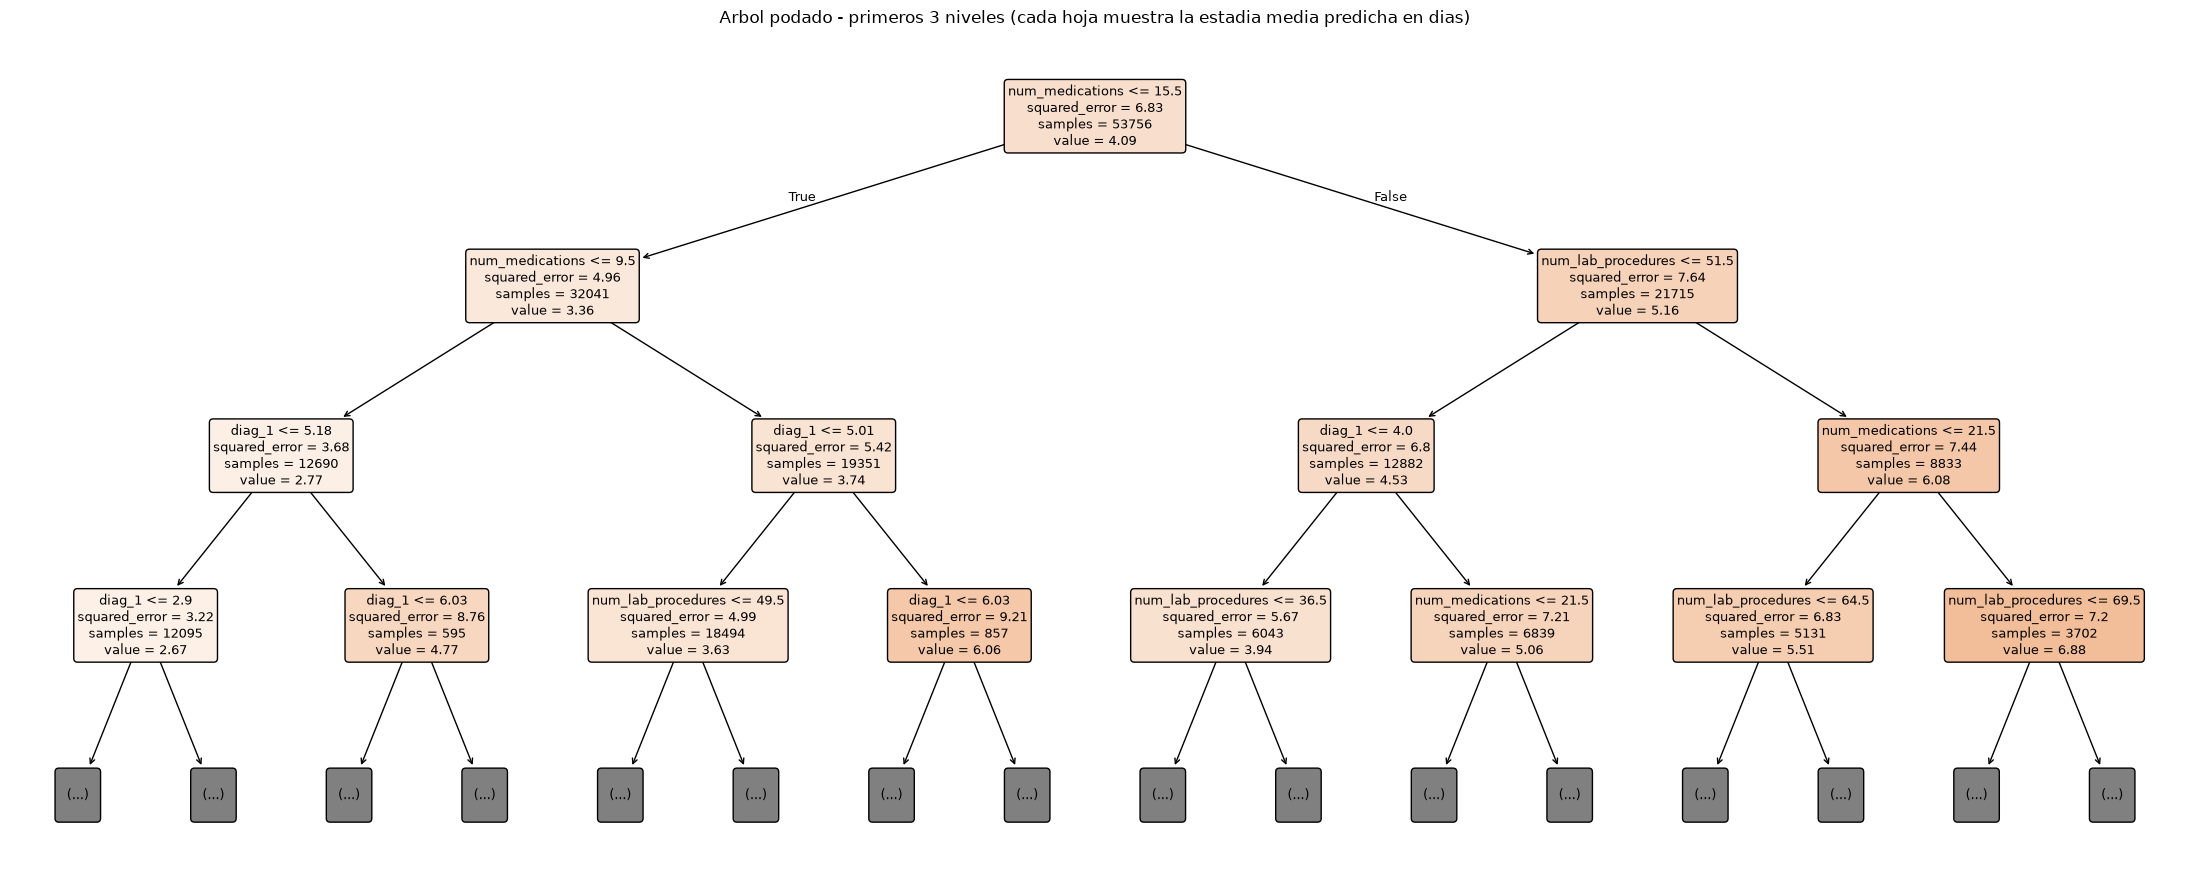

In [7]:
# --- Visualizacion: primeros 3 niveles del arbol podado ---
from sklearn.tree import plot_tree

nombres_features = list(
    pipe_podado.named_steps["preprocesador"].get_feature_names_out()
)
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(
    arbol, max_depth=3, feature_names=nombres_features,
    filled=True, rounded=True, fontsize=9, precision=2, ax=ax,
)
ax.set_title(
    "Arbol podado - primeros 3 niveles (cada hoja muestra la estadia media "
    "predicha en dias)"
)
plt.tight_layout(); plt.show()

## Cierre

El contraste queda documentado: el árbol libre memoriza (MAE de train cercano a cero con decenas de miles de hojas) y la poda por α recupera la generalización con un modelo de tamaño legible. Las primeras divisiones del árbol podado muestran qué variables separan estadías cortas de largas — anticipo del *feature importance* de los ensambles.

**Siguiente notebook (06, semana 3):** Random Forest y XGBoost — reducir la varianza del árbol promediando muchos, y el contraste `reg:absoluteerror` vs squared error (decisión D4).